<a href="https://colab.research.google.com/github/nikitask14/cross-site-heart-disease-generalisation/blob/main/NN_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###**cross-site-heart-disease-generalisation**
**Stage1: Understanding the dataset**

In [111]:
import pandas as pd
import numpy as np
# Loaded the four raw site datasets — Cleveland, Hungary, Switzerland, and VA Long Beach — from UCI using pd.read_csv().
cleveland_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
cleveland = pd.read_csv(cleveland_url, header = None)

hungarian_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.hungarian.data"
hungary = pd.read_csv(hungarian_url, header = None)

switzerland_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.switzerland.data"
switzerland = pd.read_csv(switzerland_url, header = None)

va_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.va.data"
va = pd.read_csv(va_url, header = None)


header=None

pandas had no column names(header) available, so it automatically labelled the 14 columns: 0, 1, 2, 3, ... 13

In [112]:
cleveland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       303 non-null    float64
 1   1       303 non-null    float64
 2   2       303 non-null    float64
 3   3       303 non-null    float64
 4   4       303 non-null    float64
 5   5       303 non-null    float64
 6   6       303 non-null    float64
 7   7       303 non-null    float64
 8   8       303 non-null    float64
 9   9       303 non-null    float64
 10  10      303 non-null    float64
 11  11      303 non-null    object 
 12  12      303 non-null    object 
 13  13      303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


In [113]:
hungary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       294 non-null    int64  
 1   1       294 non-null    int64  
 2   2       294 non-null    int64  
 3   3       294 non-null    object 
 4   4       294 non-null    object 
 5   5       294 non-null    object 
 6   6       294 non-null    object 
 7   7       294 non-null    object 
 8   8       294 non-null    object 
 9   9       294 non-null    float64
 10  10      294 non-null    object 
 11  11      294 non-null    object 
 12  12      294 non-null    object 
 13  13      294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


In [114]:
switzerland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       123 non-null    int64 
 1   1       123 non-null    int64 
 2   2       123 non-null    int64 
 3   3       123 non-null    object
 4   4       123 non-null    int64 
 5   5       123 non-null    object
 6   6       123 non-null    object
 7   7       123 non-null    object
 8   8       123 non-null    object
 9   9       123 non-null    object
 10  10      123 non-null    object
 11  11      123 non-null    object
 12  12      123 non-null    object
 13  13      123 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 13.6+ KB


In [115]:
va.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       200 non-null    int64 
 1   1       200 non-null    int64 
 2   2       200 non-null    int64 
 3   3       200 non-null    object
 4   4       200 non-null    object
 5   5       200 non-null    object
 6   6       200 non-null    int64 
 7   7       200 non-null    object
 8   8       200 non-null    object
 9   9       200 non-null    object
 10  10      200 non-null    object
 11  11      200 non-null    object
 12  12      200 non-null    object
 13  13      200 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 22.0+ KB


**info()** only tells us pandas did not recognize any entries as NaN. But this raw dataset may use a symbol such as **?** to represent missing data.

Pandas would treat **?** as an ordinary string, which could explain why many columns in the 4 datasets became object.

In [116]:
cleveland.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


**Note:**
1. The columns are just numbered 0 through 13. That is because the raw file contained no column names.
2. Before we inspect distributions, missing values, target, or anything else, we need to attach the correct variable names and understand them.

In [117]:
# Used the official data dictionary to map columns 0–13 to meaningful variable names rather than guessing from values.
column_names = ["age","sex", "cp", "trestbps", "chol", "fbs","restecg","thalach", "exang", "oldpeak", "slope", "ca", "thal","num"]
cleveland.columns = column_names
hungary.columns = column_names
switzerland.columns = column_names
va.columns = column_names



In [118]:
cleveland.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [119]:
hungary.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,28,1,2,130,132,0,2,185,0,0.0,?,?,?,0
1,29,1,2,120,243,0,0,160,0,0.0,?,?,?,0
2,29,1,2,140,?,0,0,170,0,0.0,?,?,?,0
3,30,0,1,170,237,0,1,170,0,0.0,?,?,6,0
4,31,0,2,100,219,0,1,150,0,0.0,?,?,?,0


In [120]:
switzerland.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,32,1,1,95,0,?,0,127,0,.7,1,?,?,1
1,34,1,4,115,0,?,?,154,0,.2,1,?,?,1
2,35,1,4,?,0,?,0,130,1,?,?,?,7,3
3,36,1,4,110,0,?,0,125,1,1,2,?,6,1
4,38,0,4,105,0,?,0,166,0,2.8,1,?,?,2


In [121]:
va.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,4,140,260,0,1,112,1,3,2,?,?,2
1,44,1,4,130,209,0,1,127,0,0,?,?,?,0
2,60,1,4,132,218,0,1,140,1,1.5,3,?,?,2
3,55,1,4,142,228,0,1,149,1,2.5,1,?,?,1
4,66,1,3,110,213,1,2,99,1,1.3,2,?,?,0


**Compare the size of each site**

This matters because unequal site sizes are one possible source of heterogeneity and will matter later when we think about pooled training.

In [122]:
print(cleveland.shape)
print(hungary.shape)
print(switzerland.shape)
print(va.shape)

(303, 14)
(294, 14)
(123, 14)
(200, 14)




```
Cleveland     303 rows
Hungary       294 rows
Switzerland   123 rows
VA Long Beach 200 rows
```



All four have the same 14-column structure, but the number of patient records differs by site.

That is our first concrete sign of heterogeneity:

same schema
≠
same dataset size

In [123]:
cleveland.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  num       303 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.3+ KB


Both **ca** and **thal** are supposed to contain numeric codes, yet pandas has stored them as object.

That suggests:

something non-numeric may be present in those columns

In [124]:
cleveland["ca"].unique()

array(['0.0', '3.0', '2.0', '1.0', '?'], dtype=object)

1. The ? is being used as a missing-value marker in the raw file.

2. Because ? is text, pandas cannot treat the whole column as numeric, so it stores the column as object.

3. This also corrects our earlier observation: 303 non-null

4. It did not mean “no missing data.” It only meant pandas had not yet recognised ? as missing.

In [125]:
cleveland["thal"].unique()

array(['6.0', '3.0', '7.0', '?'], dtype=object)

In [126]:
(cleveland["ca"] == "?").sum()

np.int64(4)

In [127]:
(cleveland["thal"] == '?').sum()

np.int64(2)

In [128]:
# clean way to do it
(cleveland == "?").sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


**Part B: Inspect Datatype of Hungarian Dataset**

In [129]:
hungary.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294 entries, 0 to 293
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       294 non-null    int64  
 1   sex       294 non-null    int64  
 2   cp        294 non-null    int64  
 3   trestbps  294 non-null    object 
 4   chol      294 non-null    object 
 5   fbs       294 non-null    object 
 6   restecg   294 non-null    object 
 7   thalach   294 non-null    object 
 8   exang     294 non-null    object 
 9   oldpeak   294 non-null    float64
 10  slope     294 non-null    object 
 11  ca        294 non-null    object 
 12  thal      294 non-null    object 
 13  num       294 non-null    int64  
dtypes: float64(1), int64(4), object(9)
memory usage: 32.3+ KB


We know that Hungary dataset has numerical values but columns 3,4,5,6,7,8,10,11 and 12 have object datatype. We should inspect for missing values.

? is only one possible missing-value marker. A raw dataset could use things like:


```
?
NA
N/A
-
unknown
blank cell
999
-1

```



In [130]:
for column in hungary.columns:
  print(column, hungary[column].unique())

age [28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51
 52 53 54 55 56 57 58 59 60 61 62 63 65 66]
sex [1 0]
cp [2 1 3 4]
trestbps ['130' '120' '140' '170' '100' '105' '110' '125' '150' '98' '112' '145'
 '190' '160' '115' '142' '180' '132' '135' '?' '108' '124' '113' '122'
 '92' '118' '106' '200' '138' '136' '128' '155']
chol ['132' '243' '?' '237' '219' '198' '225' '254' '298' '161' '214' '220'
 '160' '167' '308' '264' '166' '340' '209' '260' '211' '173' '283' '194'
 '223' '315' '275' '297' '292' '182' '200' '204' '241' '339' '147' '273'
 '307' '289' '215' '281' '250' '184' '245' '291' '295' '269' '196' '268'
 '228' '358' '201' '249' '266' '186' '207' '218' '412' '224' '238' '230'
 '163' '240' '280' '257' '263' '276' '284' '195' '227' '253' '187' '202'
 '328' '168' '216' '129' '190' '188' '179' '210' '272' '180' '100' '259'
 '468' '274' '320' '221' '309' '312' '171' '208' '246' '305' '217' '365'
 '344' '394' '256' '326' '277' '270' '229' '85' '347' '251' '222' '2

This systematic inspection tells us several useful things.

For Hungary, the suspicious non-numeric marker we actually observe is consistently:

?

In [131]:
(hungary == "?").sum()

,0
age,0
sex,0
cp,0
trestbps,1
chol,23
fbs,8
restecg,1
thalach,1
exang,1
oldpeak,0


1. slope → 190 missing out of 294
2. ca    → 291 missing out of 294
3. thal  → 266 missing out of 294

**Part C: Inspect Datatype of Switzerland Dataset**

In [132]:
switzerland.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       123 non-null    int64 
 1   sex       123 non-null    int64 
 2   cp        123 non-null    int64 
 3   trestbps  123 non-null    object
 4   chol      123 non-null    int64 
 5   fbs       123 non-null    object
 6   restecg   123 non-null    object
 7   thalach   123 non-null    object
 8   exang     123 non-null    object
 9   oldpeak   123 non-null    object
 10  slope     123 non-null    object
 11  ca        123 non-null    object
 12  thal      123 non-null    object
 13  num       123 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 13.6+ KB


In [133]:
for column in switzerland.columns:
  print(column, switzerland[column].unique())

age [32 34 35 36 38 40 41 42 43 45 46 47 48 50 51 52 53 54 55 56 57 58 59 60
 61 62 63 64 65 66 67 68 69 70 72 73 74]
sex [1 0]
cp [1 4 3 2]
trestbps ['95' '115' '?' '110' '105' '100' '135' '150' '125' '145' '140' '155'
 '160' '120' '130' '165' '80' '180' '170' '200' '185']
chol [0]
fbs ['?' '0' '1']
restecg ['0' '?' '1' '2']
thalach ['127' '154' '130' '125' '166' '156' '179' '128' '150' '120' '144' '176'
 '99' '122' '145' '140' '138' '133' '113' '118' '149' '124' '110' '139'
 '92' '104' '170' '163' '60' '126' '82' '95' '115' '135' '141' '155' '83'
 '97' '98' '100' '148' '103' '121' '131' '182' '105' '175' '94' '119'
 '143' '63' '70' '77' '117' '123' '134' '72' '78' '109' '86' '114' '93'
 '67' '90' '108' '136' '?' '157']
exang ['0' '1' '?']
oldpeak ['.7' '.2' '?' '1' '2.8' '0' '-1.1' '1.6' '-1.5' '1.5' '2' '.5' '-.1'
 '-2.6' '2.1' '-.7' '2.2' '3' '.1' '.3' '-2' '-1' '1.8' '1.4' '2.6' '.9'
 '2.4' '1.1' '.4' '2.5' '1.7' '-.8' '-.5' '-.9' '3.7' '1.3']
slope ['1' '?' '2' '3']
ca ['?' '1' '

In [134]:
(switzerland == "?").sum()

,0
age,0
sex,0
cp,0
trestbps,2
chol,0
fbs,75
restecg,1
thalach,1
exang,1
oldpeak,6


1. 123 patients
2. explicit "?" missingness in several variables
3. ca missing for 118/123
4. thal missing for 52/123
5. fbs missing for 75/123
6. AND cholesterol appears unavailable for the entire site

**Part D: Inspect Datatype of VA Dataset**


In [135]:
va.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   age       200 non-null    int64 
 1   sex       200 non-null    int64 
 2   cp        200 non-null    int64 
 3   trestbps  200 non-null    object
 4   chol      200 non-null    object
 5   fbs       200 non-null    object
 6   restecg   200 non-null    int64 
 7   thalach   200 non-null    object
 8   exang     200 non-null    object
 9   oldpeak   200 non-null    object
 10  slope     200 non-null    object
 11  ca        200 non-null    object
 12  thal      200 non-null    object
 13  num       200 non-null    int64 
dtypes: int64(5), object(9)
memory usage: 22.0+ KB


In [136]:
for column in va.columns:
  print(column, va[column].unique())

age [63 44 60 55 66 65 56 59 62 57 46 58 64 74 52 69 51 54 77 61 40 41 42 53
 68 67 72 75 49 35 43 48 50 45 76 70 71 38 37]
sex [1 0]
cp [4 3 2 1]
trestbps ['140' '130' '132' '142' '110' '120' '150' '180' '160' '126' '?' '128'
 '170' '152' '116' '124' '0' '122' '144' '154' '125' '104' '136' '134'
 '138' '178' '146' '135' '158' '106' '112' '102' '96' '172' '155' '156'
 '118' '100' '190' '114' '127']
chol ['260' '209' '218' '228' '213' '0' '236' '267' '166' '220' '177' '186'
 '100' '171' '230' '281' '203' '277' '233' '240' '153' '224' '316' '311'
 '270' '217' '214' '252' '339' '216' '276' '458' '241' '384' '297' '248'
 '308' '208' '227' '210' '245' '225' '198' '195' '161' '258' '235' '305'
 '223' '282' '349' '?' '160' '312' '283' '142' '211' '306' '222' '202'
 '197' '204' '274' '192' '298' '272' '200' '261' '181' '221' '175' '219'
 '310' '232' '273' '182' '292' '289' '193' '170' '369' '173' '271' '244'
 '285' '243' '237' '165' '287' '256' '264' '226' '207' '284' '337' '254'
 '300' '333' 

In [137]:
(va == "?").sum()

,0
age,0
sex,0
cp,0
trestbps,56
chol,7
fbs,7
restecg,0
thalach,53
exang,53
oldpeak,56


## First-Pass Multi-Site Dataset Inspection

The four processed UCI Heart Disease site datasets were loaded separately:

* Cleveland
* Hungary
* Switzerland
* VA Long Beach

All four datasets use the same 14-variable schema, but they differ in both sample size and data completeness.

Initial inspection included:

* dataset shapes,
* column names and data types,
* unique-value inspection,
* identification of `?` as an explicit missing-value marker,
* column-wise missing-value counts for each site.

An important observation is that sharing the same schema does **not** mean the sites contain equally complete data. Hungary, Switzerland, and VA Long Beach have substantial missingness in several variables, particularly `ca`, `thal`, and `slope`.

The Switzerland cholesterol column also requires further investigation because all observed values are `0`, suggesting that missingness may not always be represented explicitly by `?`.

No preprocessing or missing-value handling decisions have been made yet. This stage is strictly concerned with understanding the raw site data before modifying it.


In [138]:
# Standardised confirmed missing markers to NaN but deliberately did not impute yet.
cleveland = cleveland.replace("?",np.nan)
hungary = hungary.replace("?",np.nan)
switzerland = switzerland.replace("?",np.nan)
va = va.replace("?", np.nan)

In [139]:
switzerland["chol"] = switzerland["chol"].replace(0, np.nan)
va["chol"] = va["chol"].replace(0,np.nan)

In [140]:
# Verifying that the cleaning of "?" and "0" worked correctly

print((cleveland == "?").sum())
print((hungary == "?").sum())
print((switzerland == "?").sum())
print((va == "?").sum())
print((switzerland["chol"] == 0).sum())
print((va["chol"] == 0).sum())


age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
num         0
dtype: int64
0
0


In [141]:
#checking how many columns have NaN now. These are the same "?"
#that we replaced with NaN
print(cleveland.isna().sum())
print(hungary.isna().sum())
print(switzerland.isna().sum())
print(va.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
dtype: int64
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64
age           0
sex           0
cp            0
trestbps      2
chol        123
fbs          75
restecg       1
thalach       1
exang         1
oldpeak       6
slope        17
ca          118
thal         52
num           0
dtype: int64
age           0
sex           0
cp            0
trestbps     56
chol          7
fbs           7
restecg       0
thalach      53
exang        53
oldpeak      56
slope       102
ca          198
thal        166
num           0
dtype: int64


In [142]:
for df in [cleveland, hungary, switzerland, va]:
  df[column_names] = df[column_names].apply(pd.to_numeric)

Converted the original UCI feature columns to numeric dtype after replacing documented missing-value markers with `NaN`.  

This ensures numerical preprocessing such as median imputation and standardisation operates on true numeric values.

In [143]:
cleveland.dtypes
cleveland[column_names].dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


### Stage 2: Understand the target

- original num values
- site-wise class balance
- binary target justified
- binary target created and verified

In [144]:
cleveland["num"].unique()

array([0, 2, 1, 3, 4])

In [145]:
hungary["num"].unique()

array([0, 1])

In [146]:
switzerland["num"].unique()

array([1, 3, 2, 0, 4])

In [147]:
va["num"].unique()

array([2, 0, 1, 3, 4])

Hungary only contains 0 and 1, while the other three contain 0–4, the concern that it raises if we tried to treat num as a 5-class target across all four sites is that we have no examples at all for classes 2, 3, and 4 in the hungary dataset.

That creates a serious cross-site comparability problem. A model evaluated on Hungary could never be tested on those classes there, because they simply do not exist in that site's labels.

Binary presence/absence gives all four sites a common, interpretable target and keeps the focus on cross-site generalisation, which is what we want to study.

A 5-class version would introduce a second research problem—unequal/missing class representation across sites—before we have even learned the centralized multi-site workflow.

Before recoding, we want to know the class distribution at each site:

0      → disease absent

1–4    → disease present

Why this matters: two sites can have the same target definition but very different proportions of positive and negative cases. That would be another form of site heterogeneity and could later affect both training and how we interpret metrics.

In [148]:
(cleveland["num"] == 0).sum()

np.int64(164)

So, out of 303 examples we have 164 as zero so (303 - 164) are 1- 4

In [149]:
(hungary["num"] == 0).sum()

np.int64(188)

Out of 294, 188 are zero.

In [150]:
(switzerland["num"] == 0).sum()

np.int64(8)

Out of 123, 8 are zero

In [151]:
(va["num"] == 0).sum()

np.int64(51)

Out of 200, 51 are 0.

Cleveland: 164 absent, 139 present

Hungary: 188 absent, 106 present

Switzerland: 8 absent, 115 present

VA Long Beach: 51 absent, 149 present


---

```
The proportions are very different across sites:

Cleveland: ~54% absent / 46% present

Hungary: ~64% absent / 36% present
Switzerland: ~7% absent / 93% present
VA: ~26% absent / 75% present

That is a major finding already: target distribution differs substantially by site.

```



In [152]:
cleveland["binary_target"] = (cleveland["num"]!= 0).astype(int)

In [153]:
hungary["binary_target"] = (hungary["num"]!= 0).astype(int)

In [154]:
switzerland["binary_target"] = (switzerland["num"] != 0 ).astype(int)

In [155]:
va["binary_target"] = (va["num"]!= 0).astype(int)

## Target Definition

The original UCI Heart Disease target, `num`, contains values from `0` to `4`.

Across the four sites:

* Cleveland, Switzerland, and VA Long Beach contain values `0–4`.
* Hungary contains only `0` and `1`.

For this capstone, the target is converted to a binary variable:

* `0` → heart disease absent
* `1` → heart disease present, corresponding to original `num` values `1–4`

The original `num` column is retained for traceability, while `binary_target` is used for modelling.

## Prediction Problem

The capstone therefore uses a **binary classification** task:

> Given the patient features, predict whether heart disease is absent or present.

Binary classification was chosen because it provides a common target definition across all four sites and keeps the study focused on **cross-site generalisation**, rather than introducing the additional complication of uneven availability of the original `1–4` target levels across sites.


In [156]:
# Check if binary conversion for the target label worked
print(cleveland["binary_target"].unique())
print(switzerland["binary_target"].unique())
print(hungary["binary_target"].unique())
print(va["binary_target"].unique())

[0 1]
[1 0]
[0 1]
[1 0]


## Research Problem

The UCI Heart Disease collection contains data from four clinical sites: Cleveland, Hungary, Switzerland, and VA Long Beach.

These sites are heterogeneous. They differ in sample size, data completeness, missing-value patterns, and target distributions. Cleveland, Switzerland, and VA Long Beach contain the original target values `0–4`, whereas Hungary contains only `0` and `1`.

To provide a common prediction task across all four sites, the original target is converted into a binary classification problem:

* `0` → heart disease absent
* `1–4` → heart disease present

The central research problem is therefore:

> **Does a model trained on centrally pooled data from four heterogeneous clinical sites generalise consistently when evaluated separately on each site?**

The capstone investigates **cross-site generalisation under centralized learning**, with particular attention to whether aggregate pooled performance may hide differences in site-specific performance.


In [157]:
# Without an extra column, an individual row no longer tells us
# whether it came from Cleveland, Hungary, Switzerland, or VA.
cleveland["site"] ="cleveland"
hungary["site"] = "hungary"
switzerland["site"] = "switzerland"
va["site"] = "va"

#Simple check to see if now datasets have a metadata column
va.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,binary_target,site
0,63,1,4,140.0,260.0,0.0,1,112.0,1.0,3.0,2.0,NaN,NaN,2,1,va
1,44,1,4,130.0,209.0,0.0,1,127.0,0.0,0.0,NaN,NaN,NaN,0,0,va
2,60,1,4,132.0,218.0,0.0,1,140.0,1.0,1.5,3.0,NaN,NaN,2,1,va
3,55,1,4,142.0,228.0,0.0,1,149.0,1.0,2.5,1.0,NaN,NaN,1,1,va
4,66,1,3,110.0,213.0,1.0,2,99.0,1.0,1.3,2.0,NaN,NaN,0,0,va


In [158]:
pooled_data = pd.concat([cleveland, hungary, switzerland, va],
                        ignore_index = True)

ignore_index = True

As each original DataFrame has its own row index starting from 0.
After stacking, we would otherwise have repeated index values from each site if we don't use ingore_index = True.

In [159]:
pooled_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   age            920 non-null    float64
 1   sex            920 non-null    float64
 2   cp             920 non-null    float64
 3   trestbps       861 non-null    float64
 4   chol           767 non-null    float64
 5   fbs            830 non-null    float64
 6   restecg        918 non-null    float64
 7   thalach        865 non-null    float64
 8   exang          865 non-null    float64
 9   oldpeak        858 non-null    float64
 10  slope          611 non-null    float64
 11  ca             309 non-null    float64
 12  thal           434 non-null    float64
 13  num            920 non-null    int64  
 14  binary_target  920 non-null    int64  
 15  site           920 non-null    object 
dtypes: float64(13), int64(2), object(1)
memory usage: 115.1+ KB




```
920 rows = 303 + 294 + 123 + 200, so all four sites are represented.
16 columns = original 14 + binary_target + site.
Missingness is still preserved rather than silently filled.
Several columns are still object.
That is because many numeric values originally came in as strings when ? was present.
Replacing ? with NaN does not automatically convert those columns back to numeric.
```



In [160]:
# verify the site column in the pooled dataset to make sure
# each site's rows survived pooling correctly
print((pooled_data["site"] == "cleveland").sum())
print((pooled_data["site"] == "hungary").sum())
print((pooled_data["site"] == "switzerland").sum())
print((pooled_data["site"] == "va").sum())

303
294
123
200


## Site-Wise Train, Validation, and Test Split

To support cross-site evaluation, each site's data is split separately before the corresponding training, validation, and test portions are pooled.

For each site:

* `60%` of examples are used for training.
* `20%` are used for validation.
* `20%` are reserved for final testing.

The split is performed in two stages:

1. Separate `20%` of the site data as the test set.
2. Split the remaining `80%` into training and validation data, using `25%` of that portion for validation.

This produces the final `60/20/20` split.

The binary target is stratified during both splitting stages so that the proportion of disease-absent and disease-present examples is preserved as closely as possible within each subset.

The predictor set contains the 13 clinical variables. The following columns are excluded from the model inputs:

* `num` — original target retained for traceability
* `binary_target` — the target to be predicted
* `site` — metadata retained for site-specific evaluation

Splitting each site separately ensures that Cleveland, Hungary, Switzerland, and VA Long Beach are represented in the training, validation, and test sets. The corresponding site-specific subsets can later be pooled for centralized model training while still allowing evaluation on each site separately.


In [161]:
from sklearn.model_selection import train_test_split

In [162]:
feature_columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal"
]

In [163]:
X_cleveland = cleveland[feature_columns]
y_cleveland = cleveland["binary_target"]

x_train_val, x_test_cleveland, y_train_val, y_test_cleveland = train_test_split(
    X_cleveland,
    y_cleveland,
    test_size = 0.20,
    random_state = 42,
    stratify = y_cleveland

)

x_train_cleveland, x_val_cleveland, y_train_cleveland, y_val_cleveland = train_test_split(
    x_train_val,
    y_train_val,
    test_size = 0.25,
    random_state = 42,
    stratify = y_train_val
)

In [164]:
X_hungary = hungary[feature_columns]
y_hungary = hungary["binary_target"]

x_train_val, x_test_hungary, y_train_val, y_test_hungary = train_test_split(
    X_hungary,
    y_hungary,
    test_size = 0.20,
    random_state = 42,
    stratify = y_hungary

)

x_train_hungary, x_val_hungary, y_train_hungary, y_val_hungary = train_test_split(
    x_train_val,
    y_train_val,
    test_size = 0.25,
    random_state = 42,
    stratify = y_train_val
)

In [165]:
X_switzerland = switzerland[feature_columns]
y_switzerland = switzerland["binary_target"]

x_train_val, x_test_switzerland, y_train_val, y_test_switzerland = train_test_split(
    X_switzerland,
    y_switzerland,
    test_size = 0.20,
    random_state = 42,
    stratify = y_switzerland

)

x_train_switzerland, x_val_switzerland, y_train_switzerland, y_val_switzerland = train_test_split(
    x_train_val,
    y_train_val,
    test_size = 0.25,
    random_state = 42,
    stratify = y_train_val
)

In [166]:
X_va = va[feature_columns]
y_va = va["binary_target"]

x_train_val, x_test_va, y_train_val, y_test_va = train_test_split(
    X_va,
    y_va,
    test_size = 0.20,
    random_state = 42,
    stratify = y_va

)

x_train_va, x_val_va, y_train_va, y_val_va = train_test_split(
    x_train_val,
    y_train_val,
    test_size = 0.25,
    random_state = 42,
    stratify = y_train_val
)

In [167]:
# Verify shape of each of these
print(x_train_va.shape)
print(x_val_va.shape)
print(y_train_va.shape)
print(y_val_va.shape)
print(x_test_va.shape)
print(y_test_va.shape)


(120, 13)
(40, 13)
(120,)
(40,)
(40, 13)
(40,)


In [168]:
print(y_train_va.value_counts())
print("--")
print(y_val_va.value_counts())
print("--")
print(y_test_va.value_counts())

binary_target
1    89
0    31
Name: count, dtype: int64
--
binary_target
1    30
0    10
Name: count, dtype: int64
--
binary_target
1    30
0    10
Name: count, dtype: int64


## Verifying Split Sizes and Class Balance

After creating the site-specific train, validation, and test splits, two checks are performed.

### 1. Verify split sizes

The feature matrices (`X`) are checked using their shapes to confirm that the expected number of examples and predictor columns are present in each subset.

For VA Long Beach, the final split contains:

* 120 training examples
* 40 validation examples
* 40 test examples

with 13 predictor variables in each feature matrix.

### 2. Verify class balance

Class balance is checked using the target vectors (`y`), because they contain the binary labels:

* `0` → heart disease absent
* `1` → heart disease present

The feature matrices (`X`) are not used for this check because counting values in `X` would count repeated combinations of predictor values rather than the distribution of target classes.

For VA Long Beach:

* Training: 89 positive, 31 negative
* Validation: 30 positive, 10 negative
* Test: 30 positive, 10 negative

This confirms that stratification preserved the original class distribution approximately across the train, validation, and test subsets.


In [169]:
# Cleveland
print("CLEVELAND")
print("Shapes:")
print(x_train_cleveland.shape, y_train_cleveland.shape)
print(x_val_cleveland.shape, y_val_cleveland.shape)
print(x_test_cleveland.shape, y_test_cleveland.shape)

print("\nClass balance:")
print(y_train_cleveland.value_counts())
print("--")
print(y_val_cleveland.value_counts())
print("--")
print(y_test_cleveland.value_counts())


# Hungary
print("\nHUNGARY")
print("Shapes:")
print(x_train_hungary.shape, y_train_hungary.shape)
print(x_val_hungary.shape, y_val_hungary.shape)
print(x_test_hungary.shape, y_test_hungary.shape)

print("\nClass balance:")
print(y_train_hungary.value_counts())
print("--")
print(y_val_hungary.value_counts())
print("--")
print(y_test_hungary.value_counts())


# Switzerland
print("\nSWITZERLAND")
print("Shapes:")
print(x_train_switzerland.shape, y_train_switzerland.shape)
print(x_val_switzerland.shape, y_val_switzerland.shape)
print(x_test_switzerland.shape, y_test_switzerland.shape)

print("\nClass balance:")
print(y_train_switzerland.value_counts())
print("--")
print(y_val_switzerland.value_counts())
print("--")
print(y_test_switzerland.value_counts())

CLEVELAND
Shapes:
(181, 13) (181,)
(61, 13) (61,)
(61, 13) (61,)

Class balance:
binary_target
0    98
1    83
Name: count, dtype: int64
--
binary_target
0    33
1    28
Name: count, dtype: int64
--
binary_target
0    33
1    28
Name: count, dtype: int64

HUNGARY
Shapes:
(176, 13) (176,)
(59, 13) (59,)
(59, 13) (59,)

Class balance:
binary_target
0    112
1     64
Name: count, dtype: int64
--
binary_target
0    38
1    21
Name: count, dtype: int64
--
binary_target
0    38
1    21
Name: count, dtype: int64

SWITZERLAND
Shapes:
(73, 13) (73,)
(25, 13) (25,)
(25, 13) (25,)

Class balance:
binary_target
1    69
0     4
Name: count, dtype: int64
--
binary_target
1    23
0     2
Name: count, dtype: int64
--
binary_target
1    23
0     2
Name: count, dtype: int64


The main thing that stands out is Switzerland:

train: 4 negatives, 69 positives

val:   2 negatives, 23 positives

test:  2 negatives, 23 positives

So the split is technically correct, but the site itself is extremely imbalanced. That means later, a Switzerland metric based on only 2 negative test examples will be unstable and must be interpreted cautiously.

###**Pool Data training, validation and test wise**

In [170]:
pooled_train_x = pd.concat([x_train_cleveland, x_train_hungary, x_train_switzerland,x_train_va],ignore_index = True)
pooled_train_y = pd.concat([y_train_cleveland, y_train_hungary, y_train_switzerland, y_train_va],ignore_index = True)
pooled_val_x = pd.concat([x_val_cleveland,x_val_hungary, x_val_switzerland, x_val_va],ignore_index = True)
pooled_val_y = pd.concat([y_val_cleveland,y_val_hungary,y_val_switzerland, y_val_va],ignore_index = True)
pooled_test_x = pd.concat([x_test_cleveland,x_test_hungary, x_test_switzerland,x_test_va],ignore_index = True)
pooled_test_y = pd.concat([y_test_cleveland, y_test_hungary,y_test_switzerland, y_test_va],ignore_index = True)

verify the shapes of the pooled train, validation, and test sets

In [171]:
print(pooled_train_x.shape)
print(pooled_train_y.shape)
print(pooled_val_x.shape)
print(pooled_val_y.shape)
print(pooled_test_x.shape)
print(pooled_test_y.shape)

(550, 13)
(550,)
(185, 13)
(185,)
(185, 13)
(185,)


##**Stage 2: Preprocessing**

In [172]:
numerical_columns_ = ["age","trestbps", "chol","thalach","oldpeak", "ca"]
categorical_columns_ = ["sex", "cp", "fbs", "restecg", "exang","slope", "thal"]

So relative to published practice, our thinking is quite reasonable:

ca → strong precedent to exclude

thal → strong precedent to exclude

slope → also commonly excluded when combining sites

chol → more debatable

In [173]:
numerical_columns = ["age","trestbps","thalach","oldpeak"]
categorical_columns = ["sex", "cp", "restecg", "exang"]

In [174]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)

In [175]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scalar", StandardScaler())
])

In [176]:
categorical_pipeline = Pipeline([
   ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore"))

])

In [177]:
preprocessor = ColumnTransformer([
    ("numerical" , numerical_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])

##**Stage 3: Lock the Basline Model - Logistic Regression**

In [178]:
from sklearn.linear_model import LogisticRegression

In [179]:
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classification", LogisticRegression(max_iter = 1000) )
])

baseline_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'thalach',
                                                   'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'restecg',
                                                   'exang'])])),
                ('classification', LogisticRegression(max_iter=1000))])

In [180]:
baseline_model.fit(pooled_train_x, pooled_train_y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scalar',
                                                                   StandardScaler())]),
                                                  ['age', 'trestbps', 'thalach',
                                                   'oldpeak']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sex', 'cp', 'restecg',
                                                   'exang'])])),
                ('classification', LogisticRegression(max_iter=1000))])

###**Pooled Validation**

In [181]:
prediction_val = baseline_model.predict(pooled_val_x)
prediction_val.shape

(185,)

In [182]:
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, accuracy_score, f1_score)

In [183]:
baseline_cm = confusion_matrix(pooled_val_y, prediction_val)
baseline_cm

array([[67, 16],
       [20, 82]])

In [184]:
baseline_accuracy = accuracy_score(pooled_val_y, prediction_val)
baseline_accuracy

0.8054054054054054

In [185]:
baseline_precision = precision_score(pooled_val_y, prediction_val)
baseline_precision

0.8367346938775511

In [186]:
baseline_recall = recall_score(pooled_val_y, prediction_val)
baseline_recall

0.803921568627451

In [187]:
baseline_f1 = f1_score(pooled_val_y, prediction_val)
baseline_f1

0.82

###**Site-wise Validation**

In [188]:
# Manual Cleveland validation
prediction_cleveland = baseline_model.predict(x_val_cleveland)

baseline_cm_cleveland = confusion_matrix(y_val_cleveland, prediction_cleveland )
print(baseline_cm_cleveland)

baseline_accuracy_cleveland = accuracy_score(y_val_cleveland, prediction_cleveland )
print(baseline_accuracy_cleveland)

baseline_precision_cleveland = precision_score(y_val_cleveland, prediction_cleveland )
print(baseline_precision_cleveland)

baseline_recall_cleveland = recall_score(y_val_cleveland, prediction_cleveland )
print(baseline_recall_cleveland)

baseline_f1_cleveland = f1_score(y_val_cleveland, prediction_cleveland )
print(baseline_f1_cleveland)

[[29  4]
 [ 5 23]]
0.8524590163934426
0.8518518518518519
0.8214285714285714
0.8363636363636363


In [189]:
def evaluate_site(model, x, y):
  prediction = model.predict(x)
  cm = confusion_matrix(y, prediction)
  accuracy = accuracy_score(y, prediction)
  precision = precision_score(y, prediction)
  recall = recall_score(y, prediction)
  f1score = f1_score(y, prediction)


  print("Confusion Matrix:", cm)
  print("Accuracy:", accuracy)
  print("Precision", precision)
  print("Recall:", recall)
  print("F1 Score:", f1score)

evaluate_site(baseline_model, x_val_hungary,y_val_hungary )
print("")
print("")
evaluate_site(baseline_model, x_val_switzerland,y_val_switzerland )
print("")
print("")
evaluate_site(baseline_model, x_val_va,y_val_va )


Confusion Matrix: [[32  6]
 [ 7 14]]
Accuracy: 0.7796610169491526
Precision 0.7
Recall: 0.6666666666666666
F1 Score: 0.6829268292682927


Confusion Matrix: [[ 2  0]
 [ 2 21]]
Accuracy: 0.92
Precision 1.0
Recall: 0.9130434782608695
F1 Score: 0.9545454545454546


Confusion Matrix: [[ 4  6]
 [ 6 24]]
Accuracy: 0.7
Precision 0.8
Recall: 0.8
F1 Score: 0.8


**Observations:**

1. On the Cleveland validation set, the pooled model shows relatively balanced performance across the two classes, with similar numbers of false positives and false negatives and an F1 score of 0.836.

2. Hungary shows weaker validation performance than Cleveland. The main concern is lower sensitivity to the positive class: 7 of 21 disease-present cases are missed, giving a recall of 0.667.

3. Switzerland has an extremely imbalanced validation set (2 negative, 23 positive cases). Although accuracy (0.92), precision (1.00), recall (0.913), and F1 (0.955) appear high, these values must be interpreted cautiously. A model predicting every patient as positive would already achieve 92% accuracy. The model correctly classified both available negative cases, but two examples are insufficient to establish reliable performance on the negative class.

4. VA has a moderately imbalanced validation set (10 negative, 30 positive). The model detects 24 of 30 positive cases, giving recall of 0.80, but performs poorly on the negative class, correctly identifying only 4 of 10 negatives. This contributes to the relatively low overall accuracy of 0.70.

### Overall validation interpretation

The pooled logistic-regression model does not perform consistently across the four sites. Hungary shows weaker positive-class detection, with a recall of 0.667, while VA shows poor recognition of the negative class, correctly identifying only 4 of 10 negative cases.

Switzerland reports very high validation metrics, but these must be interpreted cautiously because its validation set is extremely imbalanced (2 negative vs 23 positive cases). A model predicting every patient as positive would already achieve 92% accuracy, so accuracy alone is not informative for this site.

Overall, the reasonably strong pooled validation metrics do not imply consistent performance across individual sites. Site-wise evaluation reveals differences that would be hidden if only pooled performance were reported.

**Test**

In [190]:
test_predictions = baseline_model.predict(pooled_test_x)

In [191]:
test_cm = confusion_matrix(pooled_test_y,test_predictions)
print(test_cm)

test_accuracy = accuracy_score(pooled_test_y,test_predictions)
print(test_accuracy)

test_precision = precision_score(pooled_test_y,test_predictions)
print(test_precision)

test_recall = recall_score(pooled_test_y,test_predictions)
print(test_recall)

test_f1 = f1_score(pooled_test_y,test_predictions)
print(test_f1)

[[66 17]
 [10 92]]
0.8540540540540541
0.8440366972477065
0.9019607843137255
0.8720379146919431


Now we compare the pooled validation results with the pooled test results


```
| Metric    | Validation |    Test   |
| --------- | ---------  | --------- |
| Accuracy  |      0.805 |  0.854    |
| Precision |      0.837 |  0.844    |
| Recall    |      0.804 |  0.902    |
| F1        |      0.820 |  0.872    |

```



###**Site - wise Test Evaluation**

In [192]:
def site_wise_test_evaluation(model, x, y):
  predictions = model.predict(x)
  cm = confusion_matrix(y, predictions)
  accuracy = accuracy_score(y, predictions)
  precision = precision_score(y, predictions)
  recall = recall_score(y, predictions)
  f1 = f1_score(y, predictions)

  print("Confusion Matrix:", cm)
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("F1:", f1)


site_wise_test_evaluation(baseline_model,x_test_cleveland, y_test_cleveland)
site_wise_test_evaluation(baseline_model,x_test_hungary, y_test_hungary)
site_wise_test_evaluation(baseline_model,x_test_switzerland, y_test_switzerland)
site_wise_test_evaluation(baseline_model,x_test_va, y_test_va)


Confusion Matrix: [[28  5]
 [ 2 26]]
Accuracy: 0.8852459016393442
Precision: 0.8387096774193549
Recall: 0.9285714285714286
F1: 0.8813559322033898
Confusion Matrix: [[33  5]
 [ 3 18]]
Accuracy: 0.864406779661017
Precision: 0.782608695652174
Recall: 0.8571428571428571
F1: 0.8181818181818182
Confusion Matrix: [[ 0  2]
 [ 4 19]]
Accuracy: 0.76
Precision: 0.9047619047619048
Recall: 0.8260869565217391
F1: 0.8636363636363636
Confusion Matrix: [[ 5  5]
 [ 1 29]]
Accuracy: 0.85
Precision: 0.8529411764705882
Recall: 0.9666666666666667
F1: 0.90625


### Validation → Test Performance by Site

| Site        | Accuracy        | Precision       | Recall          | F1              |
|-------------|-----------------|-----------------|-----------------|-----------------|
| Cleveland   | .852 → **.885** | .852 → .839     | .821 → **.929** | .836 → **.881** |
| Hungary     | .780 → **.864** | .700 → **.783** | .667 → **.857** | .683 → **.818** |
| Switzerland | .920 → **.760** | 1.000 → .905    | .913 → .826     | .955 → .864     |
| VA          | .700 → **.850** | .800 → .853     | .800 → **.967** | .800 → .906     |

*Values show validation → test performance for the same centrally trained logistic-regression baseline.*

### Final cross-site test interpretation

1. The pooled logistic-regression baseline shows reasonably strong overall performance on the untouched pooled test set (accuracy = 0.854, precision = 0.844, recall = 0.902, F1 = 0.872), with no substantial validation-to-test performance drop.

2. However, the site-wise results show that this pooled performance does not translate into completely consistent behaviour across all sites. Cleveland shows relatively stable and strong performance, while Hungary improves substantially on the test split, particularly in positive-class recall. VA also improves markedly, with only one false negative and a recall of 0.967 on the test set.

3. Switzerland remains the most uncertain site. Its test performance is substantially lower than its validation performance, and both splits contain only 2 negative cases compared with 23 positive cases. The model correctly classified both negatives during validation but neither during testing, demonstrating how unstable site-level conclusions can be when one class is represented by very few examples.

4. Overall, the centrally pooled model generalises reasonably well to unseen patients from several sites, particularly for detecting the positive class. However, performance varies across sites and the reliability of site-specific estimates depends strongly on local sample size and class distribution. Therefore, strong pooled performance alone is not sufficient evidence of consistent cross-site generalisation.

##**MLP Baseline**

### Bridge from sklearn preprocessing to PyTorch

In the Logistic Regression workflow, the preprocessing and model were both part of one sklearn `Pipeline`:

`raw DataFrame → preprocessing → Logistic Regression`

Because everything was inside sklearn, the preprocessing output was passed internally to the Logistic Regression model. We never had to store the processed feature matrix ourselves.

For the PyTorch MLP, the workflow changes:

`raw DataFrame → same fitted sklearn preprocessor → processed numerical matrix → PyTorch tensor → Dataset/DataLoader → MLP`

The preprocessor is already **fitted**, meaning it has already learned the training-set medians, scaling parameters, and categorical encodings from `pooled_train_x`.

We do **not fit the preprocessor again**. We reuse that fitted preprocessor and ask it to apply the same learned rules to our train/validation/test DataFrames so that the processed features become an explicit object.

That processed numerical matrix can then be converted into PyTorch tensors and used in the MLP workflow.



```
                    SAME FITTED PREPROCESSOR
                           ↓
                 ┌─────────┴─────────┐
                 ↓                   ↓
       Logistic Regression          MLP
```



In [193]:
# Access the fitted preprocessor already stored inside baseline_model.
# The preprocessor was fitted on pooled_train_x during Logistic Regression training,
# so it has already learned the training medians, scaling parameters, and category encodings.
# We are not fitting it again; we are reusing it to obtain the processed numerical matrix
# explicitly, so that matrix can be passed into the PyTorch workflow.
fitted_preprocessor = baseline_model.named_steps["preprocessor"]
fitted_preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scalar', StandardScaler())]),
                                 ['age', 'trestbps', 'thalach', 'oldpeak']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'cp', 'restecg', 'exang'])])

In [194]:
# This is the point where the raw 8 selected features become 15 processed
# features because categorical variables expand through one-hot encoding.
transformed_data = fitted_preprocessor.transform(pooled_train_x)
transformed_data
transformed_data.shape


(550, 15)

Numerical: 4 columns

sex       → 2 columns

cp        → 4 columns

restecg   → 3 columns

exang     → 2 columns


```
---------------------
```

        
Categorical = 11 columns

Total = 4 + 11 = 15

Each patient will enter the neural network with 15 input values, so the MLP's input layer will have 15 input features, not 8.

In [195]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [196]:
# Convert the transformed data to PyTorch tensor with float32.
transformed_tensor = torch.tensor(transformed_data, dtype=torch.float32)
print(transformed_tensor.shape)
print(transformed_tensor.dtype)

torch.Size([550, 15])
torch.float32


In [197]:
# Preprocessor is only for training, The target doesn't need preprocessing
transformed_target = torch.tensor(pooled_train_y, dtype = torch.float32)
print(transformed_target.shape)
print(transformed_target.dtype)

torch.Size([550])
torch.float32


In [198]:
train_dataset = TensorDataset(transformed_tensor, transformed_target)
print(train_dataset[0])
len(train_dataset)


(tensor([ 0.9207, -0.6179, -1.5652,  0.8942,  0.0000,  1.0000,  0.0000,  0.0000,
         0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  1.0000]), tensor(1.))


550

In [199]:
train_loader = DataLoader(train_dataset, batch_size = 32 ,shuffle = True)
for feature, target in train_loader:
  print(feature.shape)
  print(target.shape)
  break

torch.Size([32, 15])
torch.Size([32])


In [200]:
import torch.nn as nn

In [201]:
class MyModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer1 = nn.Linear(15,16)
    self.layer2 = nn.Linear(16,8)
    self.layer3 = nn.Linear(8,1)

  def forward(self,x):
    x = torch.relu(self.layer1(x))
    x = torch.relu(self.layer2(x))
    x = self.layer3(x)

    return x

In [202]:
# For our research baseline, we want reproducible model initialization.
# Creating the model randomly initializes its weights, even before training starts.
# Setting the seed immediately before model creation gives us the same
# starting weights each time we rerun the experiment.

torch.manual_seed(42)
model = MyModel()

Set the seed immediately before the thing whose randomness you want to reproduce.

In [203]:
optimiser = torch.optim.Adam(model.parameters(), lr = 0.001)
loss_fn = nn.BCEWithLogitsLoss()


Why use Adam instead of SGD?

Our immediate question now is that does adding small non-linear MLP to our cross site generalisation problem change performance compared to Logistic Regression.


***Adam adapts the step size for individual parameters, so it usually trains a small MLP reliably without us first spending time searching for a good SGD learning rate. That helps us keep the experiment focused on the model architecture, rather than turning this stage into an optimizer-tuning exercise.***

Also, Adam learns faster and SGD generalises better. It showed optimizer choice can affect results, not that one is universally superior.



In [204]:
transformed_val_x = fitted_preprocessor.transform(pooled_val_x)


val_x = torch.tensor(transformed_val_x, dtype = torch.float32)
val_y = torch.tensor(pooled_val_y, dtype = torch.float32)

print(val_x.shape)
print(val_x.dtype)
print(val_y.shape)
print(val_y.dtype)

torch.Size([185, 15])
torch.float32
torch.Size([185])
torch.float32


In [205]:
# train_losses and val_losses will record one loss value per epoch.
train_losses = []
val_losses = []

# Whenever a lower validation loss appears, best_val_loss is updated.
# We start it at infinity so that the first real validation loss
# will automatically be better.
best_val_loss = float("inf")
patience = 20

# If validation improves again, counter = 0.
# If counter reaches 20, training stops early.
counter = 0

In [206]:
for epoch in range(200):

  # Reset the running training loss at the start of every epoch.
  epoch_train_loss = 0
  # Put the model in training mode.
  model.train()

  # One epoch = go through all training batches once.
  for x_batch, y_batch in train_loader:

    # Clear gradients left from the previous batch.
    optimiser.zero_grad()

    # Forward pass: get one logit per patient.
    # squeeze(1) changes [batch_size, 1] -> [batch_size]
    # so logits match the target shape.
    train_logits = model(x_batch).squeeze(1)

    # Calculate the average BCE loss for this batch.
    train_loss = loss_fn(train_logits, y_batch)

    # Backpropagation: calculate gradients.
    train_loss.backward()

    # Update model parameters using the gradients.
    optimiser.step()

    # Add this batch's loss to the epoch's running loss.
    epoch_train_loss +=train_loss.item()

  # After all batches are complete for an epoch, calculate the
  # average training loss for that epoch.
  avg_train_loss = epoch_train_loss/len(train_loader)

  # Store one training-loss value per epoch for later plotting.
  train_losses.append(avg_train_loss)

  # Switch to evaluation mode after training for this epoch.
  model.eval()

  # For everything inside this block, do not build the computation graph or track gradients.”
  with torch.no_grad():

    # Forward pass on the complete validation set.
    # [185, 1] -> [185] so logits match val_y.
    val_logits = model(val_x).squeeze(1)
    val_loss = loss_fn(val_logits, val_y)

  # .item() takes a single-value PyTorch tensor like:
  # tensor(0.4372) and and converts it to a normal Python number: 0.4372
  # That makes it convenient to store in lists, print, log, and plot later.
  val_losses.append(val_loss.item())

  if val_loss.item() < best_val_loss:
    best_val_loss = val_loss.item()
    counter = 0
    torch.save(model.state_dict(), "best_model.pth")


  else:
    counter += 1

  if counter >= patience:
    print(f"Early stopping at epoch: {epoch}")
    break


  if epoch % 10 == 0:
    print(f"epoch:{epoch}",
          f"Train Loss:{avg_train_loss:.4f}",
          f"Validation Loss:{val_loss:.4f}")

model.load_state_dict(torch.load("best_model.pth"))



epoch:0 Train Loss:0.6861 Validation Loss:0.6831
epoch:10 Train Loss:0.4920 Validation Loss:0.4635
epoch:20 Train Loss:0.4455 Validation Loss:0.4192
epoch:30 Train Loss:0.4247 Validation Loss:0.4092
epoch:40 Train Loss:0.4132 Validation Loss:0.4084
epoch:50 Train Loss:0.4061 Validation Loss:0.4088
Early stopping at epoch: 55


<All keys matched successfully>

For each training batch, BCEWithLogitsLoss() gives us one mean batch loss. Across ~18 batches, we accumulate those batch losses and then divide by the number of batches to get one training-loss summary for that epoch

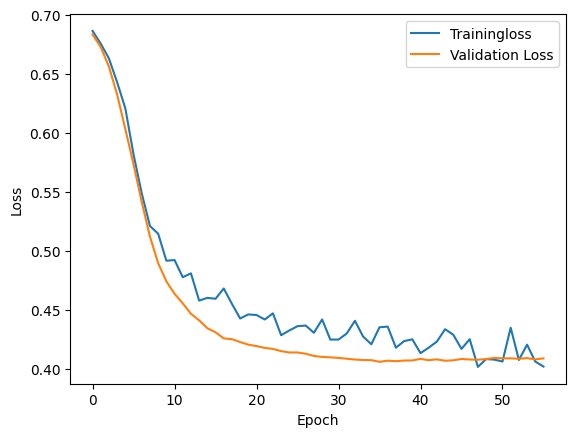

In [207]:
# matplotlib is a Python plotting library.
# pyplot contains the plotting functions
# plt simply gives it the short name plt.
# import importlib
import matplotlib.pyplot as plt
# importlib.reload(plt)

# take the values stored in train_losses and draw them as a line.
# train_losses = the actual values to plot
# label="Training Loss" = simply gives that plotted line a name
plt.plot(train_losses, label = "Trainingloss")

# take the values stored in val_losses and draw them as a line.
plt.plot(val_losses, label = "Validation Loss" )

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


### Training and Validation Loss Interpretation

Training loss decreases steadily throughout training, showing that the model continues to fit the training data.

Validation loss decreases strongly during the early epochs, then its improvement slows and begins to fluctuate/plateau while training loss continues to fall. This suggests that further training is no longer producing consistent improvement on unseen validation data.

Early stopping therefore prevents unnecessary training beyond the point of best validation performance and helps reduce overfitting.

The existing val_logits in memory were produced before we restored the best checkpoint. They therefore correspond to the model at the last validation epoch, not necessarily the best model.
So we first need a fresh forward pass using the restored best model.

In [208]:
model.eval()
# During training we needed gradients because we were changing the weights.
# Now we are not changing any weights, so we tell PyTorch:
# Don't calculate or store gradients for what I'm about to do.
with torch.no_grad():

  # forward pass
  val_logits = model(val_x).squeeze(1)

val_logits.shape

# python slicing
# start from the beginning, and take values up to—but not including—index 5.
val_logits[:5]

tensor([-0.5302, -2.0051, -0.0231,  0.0654,  1.7709])

negative logit → leans toward class 0

positive logit → leans toward class 1

logit near 0  → model is close to the decision boundary


---



**So just from these five:**

-0.5302  → leaning 0

-2.0051  → more strongly leaning 0

-0.0231  → almost exactly on the boundary

 0.0654  → barely leaning 1

 1.7709  → more strongly leaning 1


 1.7709 does not mean 177% probability, and -2.0051 does not mean a negative probability. Logits live on an unrestricted scale from -∞ to +∞.

In [209]:
val_probabilities = torch.sigmoid(val_logits)
val_probabilities[:5]
# PyTorch compares every one of the 185 probabilities against 0.5
#  and produces Boolean values:
# .int() converts false -> 0 and true -> 1
val_predictions = (val_probabilities >=0.5).int()
val_predictions[:5]

tensor([0, 0, 0, 1, 1], dtype=torch.int32)

In [210]:
# Convert this PyTorch tensor into a NumPy array containing the same values.
val_predictions_np = val_predictions.numpy()
val_y_np = val_y.numpy()

In [211]:
mlp_pooled_cm = confusion_matrix(val_y_np,val_predictions_np)
print(mlp_pooled_cm)

mlp_pooled_accuracy = accuracy_score(val_y_np,val_predictions_np)
print(mlp_pooled_accuracy)

mlp_pooled_precision = precision_score(val_y_np,val_predictions_np)
print(mlp_pooled_precision)

mlp_pooled_recall = recall_score(val_y_np,val_predictions_np)
print(mlp_pooled_recall)

mlp_pooled_f1 = f1_score(val_y_np,val_predictions_np)
print(mlp_pooled_f1)

[[63 20]
 [17 85]]
0.8
0.8095238095238095
0.8333333333333334
0.821256038647343


###**site-wise validation on MLP**

In [212]:
# Apply already fitted preprocessor to the x_val_cleveland
# Not done on y_vaal_cleveland as the feature preprocessing pipeline is designed only for X.
transformed_cleveland_data = fitted_preprocessor.transform(x_val_cleveland)

type(pooled_val_y), type(y_val_cleveland)
# Conveet the transformed data into tensors for PyTorch to use
cleveland_val_x = torch.tensor(transformed_cleveland_data, dtype = torch.float32)

# The values do not change.
# We are only removing the pandas-specific row labels before handing the data to PyTorch.
cleveland_val_y = torch.tensor(y_val_cleveland.to_numpy(), dtype = torch.float32)

print(cleveland_val_x.shape)
print(cleveland_val_y.shape)

model.eval()

with torch.no_grad():
  cleveland_mlp_logits = model(cleveland_val_x).squeeze(1)
  cleveland_mlp_prob = torch.sigmoid(cleveland_mlp_logits)
  cleveland_mlp_pred = (cleveland_mlp_prob >=0.50).int()

print(type(cleveland_mlp_pred))
print(type(cleveland_val_y))

# Convert into numpy array for computing classification metrics
y_val_cleveland_np = y_val_cleveland.to_numpy()

# pandas Series → .to_numpy()
# PyTorch Tensor → .numpy()

cleveland_mlp_pred_np = cleveland_mlp_pred.numpy()



torch.Size([61, 15])
torch.Size([61])
<class 'torch.Tensor'>
<class 'torch.Tensor'>


In [213]:
mlp_cleveland_cm = confusion_matrix(y_val_cleveland_np, cleveland_mlp_pred_np)
print(mlp_cleveland_cm)

mlp_cleveland_accuracy = accuracy_score(y_val_cleveland_np, cleveland_mlp_pred_np)
print(mlp_cleveland_accuracy)

mlp_cleveland_precision = precision_score(y_val_cleveland_np, cleveland_mlp_pred_np)
print(mlp_cleveland_precision)

mlp_cleveland_recall = recall_score(y_val_cleveland_np, cleveland_mlp_pred_np)
print(mlp_cleveland_recall)

mlp_cleveland_f1 = f1_score(y_val_cleveland_np, cleveland_mlp_pred_np)
print(mlp_cleveland_f1)

[[26  7]
 [ 4 24]]
0.819672131147541
0.7741935483870968
0.8571428571428571
0.8135593220338984


### Cleveland Validation Performance — Logistic Regression vs MLP

| Metric | Logistic Regression | MLP |
|---|---:|---:|
| Accuracy | 0.852 | 0.820 |
| Precision | 0.852 | 0.774 |
| Recall | 0.821 | 0.857 |
| F1-score | 0.836 | 0.814 |

On the Cleveland validation set, the MLP achieves higher recall, while Logistic Regression has higher accuracy, precision, and F1-score.

In [214]:
transformed_hungary_data = fitted_preprocessor.transform(x_val_hungary)
hungary_val_x = torch.tensor(transformed_hungary_data, dtype = torch.float32)
hungary_val_y = torch.tensor(y_val_hungary.to_numpy(), dtype = torch.float32)

print(hungary_val_x.shape)
print(hungary_val_y.shape)

torch.Size([59, 15])
torch.Size([59])


In [215]:
model.eval()
with torch.no_grad():
  hungary_mlp_logits = model(hungary_val_x).squeeze(1)
  hungary_mlp_prob = torch.sigmoid(hungary_mlp_logits)
  hungary_mlp_predict = (hungary_mlp_prob >= 0.50).int()

print(type(hungary_mlp_predict))
hungary_mlp_predict_np = hungary_mlp_predict.numpy()
print(type(hungary_mlp_predict_np))

print(type(hungary_val_y))
hungary_val_y_np = hungary_val_y.numpy()
print(type(hungary_val_y_np))

mlp_hungary_cm = confusion_matrix(hungary_val_y_np, hungary_mlp_predict_np)
print(mlp_hungary_cm)

mlp_hungary_accuracy = accuracy_score(hungary_val_y_np, hungary_mlp_predict_np)
print(mlp_hungary_accuracy)

mlp_hungary_precision = precision_score(hungary_val_y_np, hungary_mlp_predict_np)
print(mlp_hungary_precision)

mlp_hungary_recall = recall_score(hungary_val_y_np, hungary_mlp_predict_np)
print(mlp_hungary_recall)

mlp_hungary_f1 = f1_score(hungary_val_y_np, hungary_mlp_predict_np)
print(mlp_hungary_f1)


<class 'torch.Tensor'>
<class 'numpy.ndarray'>
<class 'torch.Tensor'>
<class 'numpy.ndarray'>
[[32  6]
 [ 5 16]]
0.8135593220338984
0.7272727272727273
0.7619047619047619
0.7441860465116279


### Hungary Validation Performance — Logistic Regression vs MLP

| Metric | Logistic Regression | MLP |
|---|---:|---:|
| Accuracy | 0.780 | 0.814 |
| Precision | 0.700 | 0.727 |
| Recall | 0.667 | 0.762 |
| F1-score | 0.683 | 0.744 |

On the Hungary validation set, the MLP performs better than the Logistic Regression baseline across all four metrics.

In [216]:
transformed_switzerland_data = fitted_preprocessor.transform(x_val_switzerland)
switzerland_val_x = torch.tensor(transformed_switzerland_data, dtype = torch.float32)

switzerland_val_y = torch.tensor(y_val_switzerland.to_numpy(), dtype = torch.float32 )

print(switzerland_val_x.shape)
print(switzerland_val_y.shape)

model.eval()
with torch.no_grad():
  switzerland_mlp_logits = model(switzerland_val_x).squeeze(1)
  switzerland_mlp_prob = torch.sigmoid(switzerland_mlp_logits)
  switzerland_mlp_pred = (switzerland_mlp_prob >=0.50).int()

switzerland_mlp_pred_np = switzerland_mlp_pred.numpy()
switzerland_val_y_np = switzerland_val_y.numpy()

mlp_switzerland_cm = confusion_matrix(switzerland_val_y_np, switzerland_mlp_pred_np)
print(mlp_switzerland_cm)

mlp_switzerland_accuracy = accuracy_score(switzerland_val_y_np, switzerland_mlp_pred_np)
print(mlp_switzerland_accuracy)

mlp_switzerland_precision = precision_score(switzerland_val_y_np, switzerland_mlp_pred_np)
print(mlp_switzerland_precision)

mlp_switzerland_recall = recall_score(switzerland_val_y_np, switzerland_mlp_pred_np)
print(mlp_switzerland_recall)

mlp_switzerland_f1 = f1_score(switzerland_val_y_np, switzerland_mlp_pred_np)
print(mlp_switzerland_f1)

torch.Size([25, 15])
torch.Size([25])
[[ 2  0]
 [ 2 21]]
0.92
1.0
0.9130434782608695
0.9545454545454546


### Switzerland Validation Performance — Logistic Regression vs MLP

| Metric | Logistic Regression | MLP |
|---|---:|---:|
| Accuracy | 0.920 | 0.920 |
| Precision | 1.000 | 1.000 |
| Recall | 0.913 | 0.913 |
| F1-score | 0.955 | 0.955 |

The Logistic Regression and MLP models produce identical validation performance on the Switzerland split.

However, the Switzerland validation set contains only 25 patients (2 negatives and 23 positives), so these metrics should be interpreted cautiously.

In [217]:
transformed_va_data = fitted_preprocessor.transform(x_val_va)
va_val_x = torch.tensor(transformed_va_data, dtype = torch.float32)

va_val_y = torch.tensor(y_val_va.to_numpy(), dtype = torch.float32)

print(va_val_x.shape)
print(va_val_y.shape)

model.eval()
with torch.no_grad():
  va_mlp_logits = model(va_val_x).squeeze(1)
  va_mlp_prob = torch.sigmoid(va_mlp_logits)
  va_mlp_pred = (va_mlp_prob >= 0.50).int()

print(type(va_val_y))
print(type(va_mlp_pred))

va_val_y_np = va_val_y.numpy()
va_mlp_pred_np = va_mlp_pred.numpy()

mlp_va_cm = confusion_matrix(va_val_y_np, va_mlp_pred_np)
print(mlp_va_cm)

mlp_va_accuracy = accuracy_score(va_val_y_np, va_mlp_pred_np)
print(mlp_va_accuracy)

mlp_va_precision = precision_score(va_val_y_np, va_mlp_pred_np)
print(mlp_va_precision)

mlp_va_recall = recall_score(va_val_y_np, va_mlp_pred_np)
print(mlp_va_recall)

mlp_va_f1 = f1_score(va_val_y_np, va_mlp_pred_np)
print(mlp_va_f1)

torch.Size([40, 15])
torch.Size([40])
<class 'torch.Tensor'>
<class 'torch.Tensor'>
[[ 3  7]
 [ 6 24]]
0.675
0.7741935483870968
0.8
0.7868852459016393


### VA Validation Performance — Logistic Regression vs MLP

| Metric | Logistic Regression | MLP |
|---|---:|---:|
| Accuracy | 0.700 | 0.675 |
| Precision | 0.800 | 0.774 |
| Recall | 0.800 | 0.800 |
| F1-score | 0.800 | 0.787 |

The two models show similar recall on the VA validation set, but Logistic Regression has slightly higher accuracy, precision, and F1-score.

Both models show difficulty identifying negative cases at this site, where the validation split contains 30 positive and only 10 negative patients.

### Site-wise Validation Performance — Logistic Regression vs MLP

| Site | Model | Accuracy | Precision | Recall | F1-score |
|---|---|---:|---:|---:|---:|
| Cleveland | Logistic Regression | 0.852 | 0.852 | 0.821 | 0.836 |
| Cleveland | MLP | 0.820 | 0.774 | 0.857 | 0.814 |
| Hungary | Logistic Regression | 0.780 | 0.700 | 0.667 | 0.683 |
| Hungary | MLP | 0.814 | 0.727 | 0.762 | 0.744 |
| Switzerland | Logistic Regression | 0.920 | 1.000 | 0.913 | 0.955 |
| Switzerland | MLP | 0.920 | 1.000 | 0.913 | 0.955 |
| VA | Logistic Regression | 0.700 | 0.800 | 0.800 | 0.800 |
| VA | MLP | 0.675 | 0.774 | 0.800 | 0.787 |

The validation results show that the MLP does not consistently outperform Logistic Regression across sites. It improves performance on Hungary, produces identical results on Switzerland, and performs slightly worse overall on Cleveland and VA. This reinforces the importance of evaluating generalisation separately at each site rather than relying only on pooled performance.

###**MLP Pooled Test**

In [218]:
transformed_pooled_data = fitted_preprocessor.transform(pooled_test_x)
test_x_pooled = torch.tensor(transformed_pooled_data, dtype = torch.float32)

test_y_pooled = torch.tensor(pooled_test_y.to_numpy(), dtype = torch.float32)

print(test_x_pooled.shape)
print(test_y_pooled.shape)

model.eval()
with torch.no_grad():
  pooled_mlp_logits = model(test_x_pooled).squeeze(1)
  pooled_mlp_prob = torch.sigmoid(pooled_mlp_logits)
  pooled_mlp_pred = (pooled_mlp_prob >= 0.50).int()

test_y_pooled_np = test_y_pooled.numpy()
pooled_mlp_pred_np = pooled_mlp_pred.numpy()

mlp_pooled_cm = confusion_matrix(test_y_pooled_np, pooled_mlp_pred_np)
print(mlp_pooled_cm)

mlp_pooled_accuracy = accuracy_score(test_y_pooled_np, pooled_mlp_pred_np)
print(mlp_pooled_accuracy)

mlp_pooled_precision = precision_score(test_y_pooled_np, pooled_mlp_pred_np)
print(mlp_pooled_precision)

mlp_pooled_recall = recall_score(test_y_pooled_np, pooled_mlp_pred_np)
print(mlp_pooled_recall)

mlp_pooled_f1 = f1_score(test_y_pooled_np, pooled_mlp_pred_np)
print(mlp_pooled_f1)


torch.Size([185, 15])
torch.Size([185])
[[64 19]
 [10 92]]
0.8432432432432433
0.8288288288288288
0.9019607843137255
0.863849765258216


### Pooled Test Performance — Logistic Regression vs MLP

| Metric | Logistic Regression | MLP |
|---|---:|---:|
| Accuracy | 0.854 | 0.843 |
| Precision | 0.844 | 0.829 |
| Recall | 0.902 | 0.902 |
| F1-score | 0.872 | 0.864 |

On the pooled untouched test set, the MLP does not outperform the Logistic Regression baseline. Both models achieve identical recall, while Logistic Regression has slightly higher accuracy, precision, and F1-score.

This suggests that the additional nonlinear capacity of the MLP does not provide a clear overall performance advantage on the pooled test data.

In [225]:
def data_eval(X, y, preprocessor,model):
  transformed_data = preprocessor.transform(X)

  x_tensor = torch.tensor(transformed_data, dtype = torch.float32)
  y_tensor = torch.tensor(y.to_numpy(), dtype = torch.float32)

  model.eval()
  with torch.no_grad():
    logits = model(x_tensor).squeeze(1)
    prob = torch.sigmoid(logits)
    pred = (prob >= 0.50).int()


  y_tensor_np = y_tensor.numpy()
  pred_np = pred.numpy()

  cm = confusion_matrix(y_tensor_np,pred_np)
  accuracy = accuracy_score(y_tensor_np,pred_np)
  precision = precision_score(y_tensor_np,pred_np)
  recall = recall_score(y_tensor_np,pred_np)
  f1 = f1_score(y_tensor_np,pred_np)

  return cm, accuracy, precision, recall, f1


In [229]:
print("----------Cleveland Metrics------------:")
cleveland_mlp_result = data_eval(x_test_cleveland, y_test_cleveland,fitted_preprocessor, model)
print(cleveland_mlp_result)
print("----------Hungary Metrics------------:")
hungary_mlp_result = data_eval(x_test_hungary, y_test_hungary,fitted_preprocessor, model)
print(hungary_mlp_result)
print("----------Switzerland Metrics-----------:")
switzerland_mlp_result = data_eval(x_test_switzerland, y_test_switzerland,fitted_preprocessor, model)
print(switzerland_mlp_result)
print("----------VA Metrics-----------:")
va_mlp_result = data_eval(x_test_va, y_test_va,fitted_preprocessor, model)
print(va_mlp_result)

----------Cleveland Metrics------------:
(array([[27,  6],
       [ 1, 27]]), 0.8852459016393442, 0.8181818181818182, 0.9642857142857143, 0.8852459016393442)
----------Hungary Metrics------------:
(array([[32,  6],
       [ 3, 18]]), 0.847457627118644, 0.75, 0.8571428571428571, 0.8)
----------Switzerland Metrics-----------:
(array([[ 0,  2],
       [ 5, 18]]), 0.72, 0.9, 0.782608695652174, 0.8372093023255814)
----------VA Metrics-----------:
(array([[ 5,  5],
       [ 1, 29]]), 0.85, 0.8529411764705882, 0.9666666666666667, 0.90625)


### Site-wise MLP Test Performance

| Site | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| Cleveland | 0.885 | 0.818 | 0.964 | 0.885 |
| Hungary | 0.847 | 0.750 | 0.857 | 0.800 |
| Switzerland | 0.720 | 0.900 | 0.783 | 0.837 |
| VA | 0.850 | 0.853 | 0.967 | 0.906 |

The pooled MLP achieved:

- Accuracy: **0.843**
- Precision: **0.829**
- Recall: **0.902**
- F1-score: **0.864**

These site-wise results will now be used to examine whether the model trained on pooled data generalises consistently across the individual sites.

##**RESULTS**

**MLP — pooled vs site-wise test performance**

### MLP Test Performance — Pooled vs Individual Sites

| Site | Site Accuracy | Pooled Accuracy | Site Precision | Pooled Precision | Site Recall | Pooled Recall | Site F1 | Pooled F1 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Cleveland | 0.885 | 0.843 | 0.818 | 0.829 | 0.964 | 0.902 | 0.885 | 0.864 |
| Hungary | 0.847 | 0.843 | 0.750 | 0.829 | 0.857 | 0.902 | 0.800 | 0.864 |
| Switzerland | 0.720 | 0.843 | 0.900 | 0.829 | 0.783 | 0.902 | 0.837 | 0.864 |
| VA | 0.850 | 0.843 | 0.853 | 0.829 | 0.967 | 0.902 | 0.906 | 0.864 |



**1.**   A single pooled performance number is not sufficient to characterise how the pooled-trained MLP behaves across the contributing sites.

**2.**  Training on pooled data produces a model that transfers to all four contributing sites, but the quality of that transfer is not uniform.

**3.**  Good aggregate performance can conceal site-specific weaknesses. Therefore, pooled evaluation alone would give an incomplete picture of generalisation in a heterogeneous multi-site dataset.

Pooled evaluation alone is insufficient to establish consistent cross-site generalisation; the fixed pooled-trained model exhibits heterogeneous site-level performance.



### Logistic Regression Test Performance — Pooled vs Individual Sites

| Site | Site Accuracy | Pooled Accuracy | Site Precision | Pooled Precision | Site Recall | Pooled Recall | Site F1 | Pooled F1 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|
| Cleveland | 0.885 | 0.854 | 0.839 | 0.844 | 0.929 | 0.902 | 0.881 | 0.872 |
| Hungary | 0.864 | 0.854 | 0.783 | 0.844 | 0.857 | 0.902 | 0.818 | 0.872 |
| Switzerland | 0.760 | 0.854 | 0.905 | 0.844 | 0.826 | 0.902 | 0.864 | 0.872 |
| VA | 0.850 | 0.854 | 0.853 | 0.844 | 0.967 | 0.902 | 0.906 | 0.872 |

## Final Conclusion

### Research Question

**Does a model trained on centrally pooled data from four heterogeneous clinical sites generalise consistently when evaluated separately on each site?**

Both the MLP and Logistic Regression models achieved broadly similar performance on the pooled test set and across the individual sites. This suggests that models trained on the pooled data generalise reasonably well to held-out patients from each of the contributing sites.

However, the site-wise analysis revealed modest but repeatable differences that were hidden by the pooled metrics:

- Cleveland generally performed similarly to or slightly better than the pooled result.
- Hungary showed similar accuracy but lower precision, recall, and F1-score.
- Switzerland showed lower accuracy and recall but higher precision; these results should be interpreted cautiously because the test set is very small and highly imbalanced.
- VA showed similar accuracy and precision but higher recall and F1-score.

Importantly, the relative site-wise patterns were similar for both Logistic Regression and the MLP. This suggests that the observed variation may be associated more with characteristics of the individual site datasets than with a particular model architecture, although the present experiment cannot establish the cause of these differences.

### Main Finding

A single pooled performance metric provides a reasonable overall summary in this experiment, but it does not fully describe how the model behaves at each contributing site.

Therefore, **pooled evaluation should be accompanied by site-wise evaluation when assessing generalisation across heterogeneous multi-site data.**

Further analysis of class balance, feature distributions, sample size, and other site-level characteristics would be required to explain why the observed site-specific patterns occur.